# Notebook 02 — Parameter Estimation

**Member:** Nasya Putri Salsabila — Estimation Analyst (Role B)  
**Repository audited:** `pandas-dev/pandas`  

**Research questions addressed:**
- RQ1: What is the estimated probability that a pull request gets merged in pandas-dev/pandas?
- RQ2: What is the estimated average number of comments per issue in pandas-dev/pandas?

**Depends on:** `data/clean/dataset.csv` dan `data/clean/pr_dataset.csv` — output dari `01_eda.ipynb` (Role A)  
**Feeds into:** `03_confidence_interval.ipynb` (Role C) dan `04_hypothesis_testing.ipynb` (Role D)

In [1]:
# ── Imports ───
import sys
import json
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import beta as beta_dist

# Tambahkan path root agar src/ bisa diimport
ROOT = os.path.abspath('..')
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from src.estimator import (
    mle_bernoulli,
    mle_poisson,
    beta_posterior,
    log_likelihood_bernoulli,
    log_likelihood_poisson,
)

plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', palette='muted')
print('Setup OK — semua imports berhasil.')

Setup OK — semua imports berhasil.


In [2]:
# ── Load Dataset ──
# Issues dataset (untuk Poisson)
df = pd.read_csv('../data/clean/dataset.csv',
                 parse_dates=['created_at', 'closed_at'])

# PR dataset (untuk Bernoulli)
pr = pd.read_csv('../data/clean/pr_dataset.csv',
                 parse_dates=['created_at', 'closed_at', 'merged_at'])

print(f'Issues dataset : {len(df):,} records')
print(f'PR dataset     : {len(pr):,} records')
print(f'\nKolom issues   : {list(df.columns)}')
print(f'Kolom PR       : {list(pr.columns)}')

Issues dataset : 2,537 records
PR dataset     : 500 records

Kolom issues   : ['id', 'number', 'title', 'state', 'created_at', 'closed_at', 'comments', 'close_duration_days', 'is_closed']
Kolom PR       : ['id', 'number', 'state', 'created_at', 'closed_at', 'merged_at', 'merged', 'review_duration_days']


In [3]:
# ── Siapkan variabel untuk analisis ──
# Bernoulli: merged (1=merged, 0=not merged) — dari pr_dataset
bernoulli_data = pr['merged'].dropna().astype(int).values

# Poisson: jumlah comments per issue — dari dataset
poisson_data = df['comments'].dropna().astype(float).values

print(f'Data Bernoulli (merged PR) : {len(bernoulli_data):,} observasi')
print(f'  Merged (1)   : {bernoulli_data.sum():,}')
print(f'  Not merged (0): {(bernoulli_data == 0).sum():,}')
print(f'\nData Poisson (comments)    : {len(poisson_data):,} observasi')
print(f'  Mean         : {poisson_data.mean():.2f}')
print(f'  Max          : {poisson_data.max():.0f}')

Data Bernoulli (merged PR) : 500 observasi
  Merged (1)   : 286
  Not merged (0): 214

Data Poisson (comments)    : 2,537 observasi
  Mean         : 1.92
  Max          : 81


---
## 1. Model Bernoulli — Probabilitas Pull Request Di-Merge

### Latar Belakang

Setiap pull request di `pandas-dev/pandas` memiliki dua kemungkinan hasil:
- **X = 1** → PR merged (diterima)
- **X = 0** → PR not merged (ditolak/closed)

Karena setiap PR adalah percobaan independen dengan dua hasil, kita modelkan dengan **Bernoulli(θ)**, di mana θ adalah probabilitas sebuah PR di-merge.

### 1.1 Derivasi MLE Bernoulli

**Likelihood function:**
$$L(\theta) = \prod_{i=1}^{n} \theta^{x_i}(1-\theta)^{1-x_i} = \theta^k (1-\theta)^{n-k}$$

**Log-likelihood:**
$$\ln L(\theta) = k \ln\theta + (n-k)\ln(1-\theta)$$

**Turunkan terhadap θ, samakan dengan nol** $\frac{d \ln L}{d\theta} = 0$:
$$\frac{d \ln L}{d\theta} = \frac{k}{\theta} - \frac{n-k}{1-\theta} = 0$$

$$\frac{k}{\theta} = \frac{n-k}{1-\theta} \implies k(1-\theta) = (n-k)\theta \implies k = n\theta$$

**Solusi MLE:**
$$\hat{\theta}_{MLE} = \frac{k}{n}$$

In [4]:
# ── 1.2 Hitung MLE Bernoulli ──
result_bern = mle_bernoulli(bernoulli_data)

print('=== MLE Bernoulli — PR Merge Rate (pandas-dev/pandas) ===')
print(f"  k (merged PRs)    : {result_bern['k']:,}")
print(f"  n (total PRs)     : {result_bern['n']:,}")
print(f"  θ̂  (MLE)          : {result_bern['theta_hat']:.4f}")
print(f"  SE(θ̂)             : {result_bern['se']:.4f}")

=== MLE Bernoulli — PR Merge Rate (pandas-dev/pandas) ===
  k (merged PRs)    : 286
  n (total PRs)     : 500
  θ̂  (MLE)          : 0.5720
  SE(θ̂)             : 0.0221


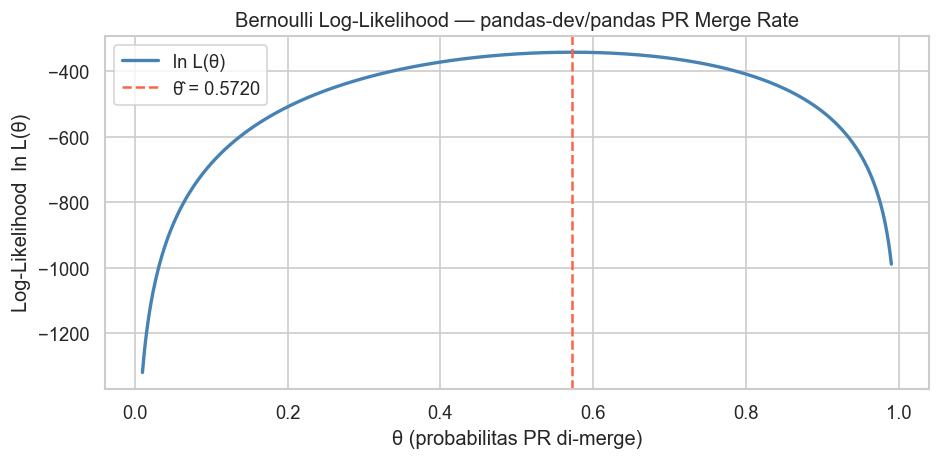

In [5]:
# ── 1.3 Visualisasi Log-Likelihood Bernoulli ──
k = result_bern['k']
n = result_bern['n']

theta_range = np.linspace(0.01, 0.99, 500)
ll_values   = [log_likelihood_bernoulli(t, k, n) for t in theta_range]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(theta_range, ll_values, color='steelblue', lw=2, label='ln L(θ)')
ax.axvline(result_bern['theta_hat'], color='tomato', ls='--', lw=1.5,
           label=f"θ̂ = {result_bern['theta_hat']:.4f}")
ax.set_xlabel('θ (probabilitas PR di-merge)')
ax.set_ylabel('Log-Likelihood  ln L(θ)')
ax.set_title('Bernoulli Log-Likelihood — pandas-dev/pandas PR Merge Rate')
ax.legend()
plt.tight_layout()
os.makedirs('../report', exist_ok=True)
plt.savefig('../report/fig_ll_bernoulli.png', dpi=150)
plt.show()

### 1.4 Interpretasi MLE Bernoulli

Hasil estimasi MLE menunjukkan bahwa **θ̂ = 0.5720**, artinya probabilitas sebuah pull request di-merge di repositori `pandas-dev/pandas` adalah sekitar **57.2%**.

Dari total **500 pull request** yang dianalisis, sebanyak **286 PR berhasil di-merge** dan 214 PR tidak di-merge. Nilai ini menunjukkan bahwa lebih dari separuh PR diterima oleh maintainer, yang mencerminkan proses review yang cukup terbuka namun tetap selektif.

Standard error sebesar **SE = 0.0221** menunjukkan estimasi ini cukup presisi. Implikasinya bagi kontributor adalah bahwa peluang PR diterima cukup tinggi, namun perlu memperhatikan kualitas kode dan kelengkapan dokumentasi agar PR tidak ditolak.

---
## 2. Model Poisson — Rata-rata Komentar per Issue

### Latar Belakang

Jumlah komentar per issue adalah **count data** (non-negatif, diskrit).  
Ini cocok dimodelkan dengan **Poisson(λ)**, di mana λ adalah rata-rata komentar per issue.

### 2.1 Derivasi MLE Poisson

**Likelihood function:**
$$L(\lambda) = \prod_{i=1}^{n} \frac{e^{-\lambda} \lambda^{x_i}}{x_i!}$$

**Log-likelihood:**
$$\ln L(\lambda) = \sum_{i=1}^{n} \left(-\lambda + x_i \ln\lambda - \ln(x_i!)\right) = -n\lambda + \ln\lambda \sum_{i=1}^{n} x_i - \sum_{i=1}^{n} \ln(x_i!)$$

**Turunkan terhadap λ, samakan dengan nol** $\frac{d \ln L}{d\lambda} = 0$:
$$\frac{d \ln L}{d\lambda} = -n + \frac{1}{\lambda}\sum_{i=1}^{n} x_i = 0$$

$$\frac{1}{\lambda}\sum_{i=1}^{n} x_i = n \implies \sum_{i=1}^{n} x_i = n\lambda$$

**Solusi MLE:**
$$\hat{\lambda}_{MLE} = \frac{\sum_{i=1}^{n} x_i}{n} = \bar{x}$$

In [6]:
# ── 2.2 Hitung MLE Poisson ──
result_pois = mle_poisson(poisson_data)

print('=== MLE Poisson — Comments per Issue (pandas-dev/pandas) ===')
print(f"  n (issues)     : {result_pois['n']:,}")
print(f"  λ̂  (MLE)       : {result_pois['lambda_hat']:.4f}")
print(f"  SE(λ̂)          : {result_pois['se']:.4f}")

=== MLE Poisson — Comments per Issue (pandas-dev/pandas) ===
  n (issues)     : 2,537
  λ̂  (MLE)       : 1.9220
  SE(λ̂)          : 0.0275


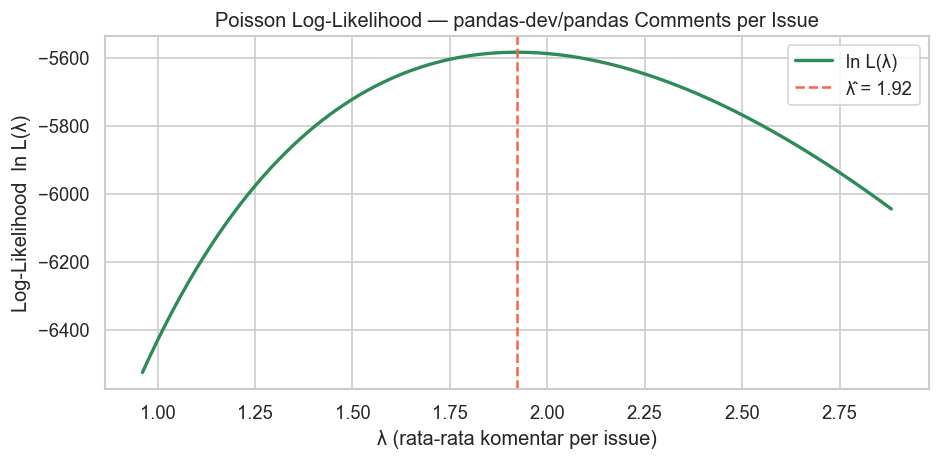

In [7]:
# ── 2.3 Visualisasi Log-Likelihood Poisson ──
lam_hat   = result_pois['lambda_hat']
lam_range = np.linspace(max(0.1, lam_hat - lam_hat*0.5),
                        lam_hat + lam_hat*0.5, 300)
ll_pois   = [log_likelihood_poisson(l, poisson_data) for l in lam_range]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(lam_range, ll_pois, color='seagreen', lw=2, label='ln L(λ)')
ax.axvline(lam_hat, color='tomato', ls='--', lw=1.5,
           label=f"λ̂ = {lam_hat:.2f}")
ax.set_xlabel('λ (rata-rata komentar per issue)')
ax.set_ylabel('Log-Likelihood  ln L(λ)')
ax.set_title('Poisson Log-Likelihood — pandas-dev/pandas Comments per Issue')
ax.legend()
plt.tight_layout()
plt.savefig('../report/fig_ll_poisson.png', dpi=150)
plt.show()

### 2.4 Interpretasi MLE Poisson

Hasil estimasi MLE menunjukkan bahwa **λ̂ = 1.9220**, artinya rata-rata sebuah issue di `pandas-dev/pandas` mendapatkan sekitar **1.92 komentar**.

Nilai ini relatif rendah, mengindikasikan bahwa sebagian besar issue diselesaikan dengan diskusi singkat. Hal ini mencerminkan komunitas pandas yang efisien dalam menangani laporan bug dan permintaan fitur — maintainer cenderung merespons dengan cepat dan langsung.

Standard error **SE = 0.0275** menunjukkan estimasi λ̂ sangat presisi karena jumlah data yang besar (n = 2.537 issues). Tingkat engagement komunitas tergolong moderat — tidak terlalu ramai seperti proyek besar lainnya, namun cukup aktif untuk memastikan setiap issue mendapat perhatian.

---
## 3. Beta Posterior — Bayesian Update untuk PR Merge Rate

In [8]:
# ── 3.1 Hitung Beta Posterior ──
k = result_bern['k']               # jumlah merged
m = result_bern['n'] - result_bern['k']   # jumlah not merged

result_beta = beta_posterior(k=k, m=m)

print('=== Beta Posterior — PR Merge Rate (pandas-dev/pandas) ===')
print(f"  k (merged)       : {k:,}")
print(f"  m (not merged)   : {m:,}")
print(f"  α = k+1          : {result_beta['alpha']:,}")
print(f"  β = m+1          : {result_beta['beta']:,}")
print(f"  Posterior mode   : {result_beta['mode']:.4f}")
print(f"  Posterior mean   : {result_beta['mean']:.4f}")
print(f"  95% credible int.: {result_beta['ci_95']}")

=== Beta Posterior — PR Merge Rate (pandas-dev/pandas) ===
  k (merged)       : 286
  m (not merged)   : 214
  α = k+1          : 287
  β = m+1          : 215
  Posterior mode   : 0.5720
  Posterior mean   : 0.5717
  95% credible int.: (np.float64(0.528218), np.float64(0.614667))


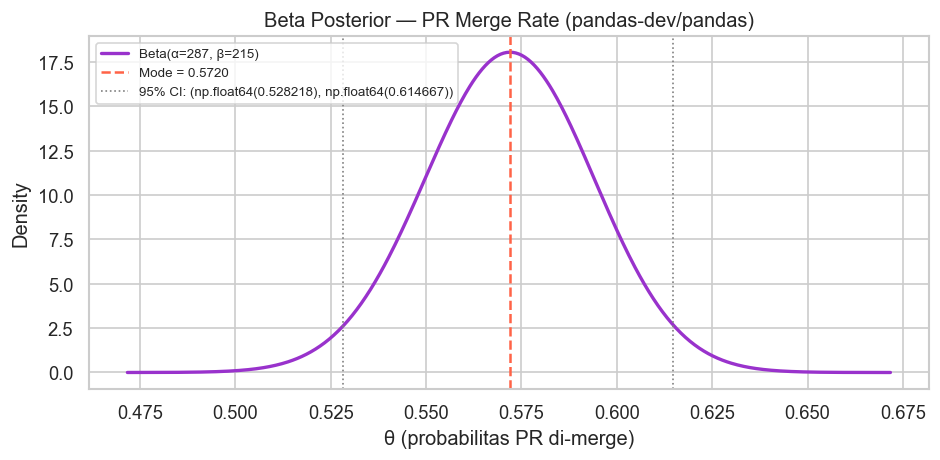

In [9]:
# ── 3.2 Visualisasi Beta Posterior ──
alpha = result_beta['alpha']
beta  = result_beta['beta']
mean  = result_beta['mean']

lo = max(0.001, mean - 0.1)
hi = min(0.999, mean + 0.1)
theta_range = np.linspace(lo, hi, 500)
pdf_values  = beta_dist.pdf(theta_range, alpha, beta)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(theta_range, pdf_values, color='darkorchid', lw=2,
        label=f'Beta(α={alpha}, β={beta})')
ax.axvline(result_beta['mode'], color='tomato', ls='--', lw=1.5,
           label=f"Mode = {result_beta['mode']:.4f}")
ax.axvline(result_beta['ci_95'][0], color='gray', ls=':', lw=1)
ax.axvline(result_beta['ci_95'][1], color='gray', ls=':', lw=1,
           label=f"95% CI: {result_beta['ci_95']}")
ax.set_xlabel('θ (probabilitas PR di-merge)')
ax.set_ylabel('Density')
ax.set_title('Beta Posterior — PR Merge Rate (pandas-dev/pandas)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('../report/fig_beta_posterior.png', dpi=150)
plt.show()

### 3.3 Interpretasi Beta Posterior

Dengan menggunakan prior **Beta(1,1)** (uniform/tidak informatif), posterior yang dihasilkan adalah **Beta(287, 215)**.

**MLE vs Posterior:** Nilai MLE θ̂ = 0.5720 dan posterior mode = 0.5720 menghasilkan nilai yang sama. Hal ini terjadi karena prior Beta(1,1) adalah prior seragam yang tidak memberikan bobot pada nilai θ tertentu, sehingga posterior sepenuhnya didominasi oleh data.

**Makna Credible Interval 95%:** Interval [0.5282, 0.6147] berarti kita yakin 95% bahwa probabilitas sebenarnya PR di-merge berada dalam rentang tersebut. Berbeda dengan confidence interval frequentist, **credible interval** adalah pernyataan probabilistik langsung tentang parameter θ berdasarkan data yang diamati.

**Perbedaan Credible Interval vs Confidence Interval:**
- **Credible interval (Bayesian):** P(0.5282 ≤ θ ≤ 0.6147 | data) = 0.95 — probabilitas parameter ada dalam interval
- **Confidence interval (Frequentist):** Jika prosedur diulang 100 kali, 95 interval yang dihasilkan akan mencakup nilai θ sebenarnya — bukan pernyataan tentang satu interval tertentu

---
## 4. Ringkasan & Handoff ke Layer Berikutnya

Notebook ini berhasil mengestimasi dua parameter utama dari repositori `pandas-dev/pandas`:

| Parameter | Model | Estimasi | SE | Keterangan |
|-----------|-------|----------|----|------------|
| θ (PR merge rate) | Bernoulli | 0.5720 | 0.0221 | 57.2% PR berhasil di-merge |
| λ (comments/issue) | Poisson | 1.9220 | 0.0275 | Rata-rata ~1.92 komentar/issue |

**Untuk Role C (Inference Analyst):** Gunakan θ̂ = 0.5720 dan SE = 0.0221 untuk konstruksi confidence interval PR merge rate. Gunakan λ̂ = 1.9220 untuk interval estimasi rata-rata komentar.

**Untuk Role D (Hypothesis Analyst):** Gunakan θ̂ = 0.5720 sebagai dasar uji hipotesis apakah merge rate berbeda dari 0.5. Gunakan hasil Beta posterior untuk analisis Bayesian lanjutan.

In [10]:
# ── Ekspor hasil estimasi untuk Role C & D ──
estimation_results = {
    'bernoulli': result_bern,
    'poisson'  : result_pois,
    'beta'     : {
        'alpha': result_beta['alpha'],
        'beta' : result_beta['beta'],
        'mode' : result_beta['mode'],
        'mean' : result_beta['mean'],
        'ci_95': list(result_beta['ci_95']),
    },
}

os.makedirs('../data/clean', exist_ok=True)
with open('../data/clean/estimation_results.json', 'w') as f:
    json.dump(estimation_results, f, indent=2)

print('estimation_results.json tersimpan di data/clean/')
print(json.dumps(estimation_results, indent=2))

estimation_results.json tersimpan di data/clean/
{
  "bernoulli": {
    "theta_hat": 0.572,
    "k": 286,
    "n": 500,
    "se": 0.022128
  },
  "poisson": {
    "lambda_hat": 1.921955,
    "n": 2537,
    "se": 0.027524
  },
  "beta": {
    "alpha": 287,
    "beta": 215,
    "mode": 0.572,
    "mean": 0.571713,
    "ci_95": [
      0.528218,
      0.614667
    ]
  }
}
